In [5]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def energy(f1, f2, t1, t2, p1, p2, a, m, n):
    """Returns (ext, exv, ext + exv) for the two-product-state ansatz with n particles."""
    
    s1, s2 = np.sin(t1), np.sin(t2)
    sp1, sm1 = np.sqrt(1 + s1), np.sqrt(1 - s1)
    sp2, sm2 = np.sqrt(1 + s2), np.sqrt(1 - s2)
    e1, e2 = np.exp(1j * p1), np.exp(1j * p2)
    dp = p1 - p2

    n1, n2 = abs(f1)**2, abs(f2)**2
    c12 = np.conj(f1) * f2      # Conjugate[f1] f2
    c21 = np.conj(f2) * f1      # Conjugate[f2] f1

    # overlap bases divided by 2 (so (z/2)^k stays O(1) for large n)
    # Sqrt[(-1+Sin t1)(-1+Sin t2)] = Sqrt[1-Sin t1] Sqrt[1-Sin t2]
    h12 = (np.exp(-1j * dp) * sm1 * sm2 + sp1 * sp2) / 2
    h21 = (np.exp( 1j * dp) * sm1 * sm2 + sp1 * sp2) / 2

    # kinetic term: 2^-n z^(n-1) = (z/2)^(n-1) / 2
    ext = 0.5 * n * (
        n1 * (a - a * abs(np.cos(t1)) * np.cos(p1))
        + n2 * (a - a * abs(np.cos(t2)) * np.cos(p2))
        + 0.5 * a * np.exp(-1j * p1) * c12
              * (-sm1 + e1 * sp1) * (-e2 * sm2 + sp2) * h12**(n - 1)
        + 0.5 * a * np.exp(-1j * p2) * c21
              * (-e1 * sm1 + sp1) * (-sm2 + e2 * sp2) * h21**(n - 1)
    )

    # interaction term: 2^(1-n) z^(n-2) = (z/2)^(n-2) / 2
    if n < 2:
        exv = 0.0
    else:
        q = (1 - s1) * (1 - s2)          # = (-1+Sin t1)(-1+Sin t2)
        r = (1 + s1) * (1 + s2)
        exv = 0.25 * m * (n - 1) * n * (
            n1 * (1 + s1**2)
            + n2 * (1 + s2**2)
            + 0.5 * c12 * (np.exp(-2j * dp) * q + r) * h12**(n - 2)
            + 0.5 * c21 * (np.exp( 2j * dp) * q + r) * h21**(n - 2)
        )

    return ext, exv, ext + exv

In [3]:
# energy(f1, f2, t1, t2, p1, p2, a, m, n)
a = 1
m = -1
n = 4

# ext, exv, exH = energy(1, 0, np.pi/2, -np.pi/2, 0, 0, a, m, n) # 1*allL + 0*allR

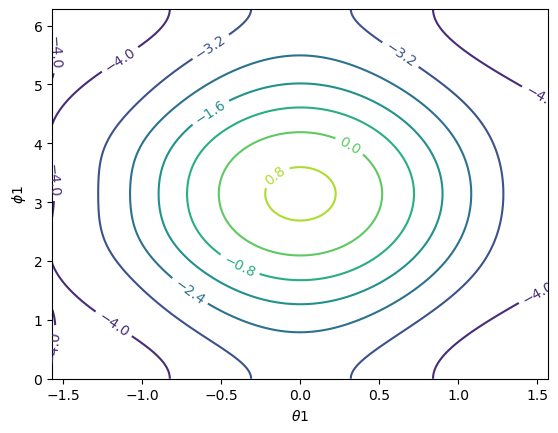

In [19]:
''' ph1 vs th1 '''

delta = 0.005
th = np.arange(-np.pi/2,np.pi/2,delta)
ph = np.arange(0.0,2*np.pi,2*delta)
Th,Ph = np.meshgrid(th,ph)
_, _, exH = energy(np.sqrt(1-1e-5), np.sqrt(1e-5), Th, -np.pi/2, Ph, 0, a, m, n)

fig, ax = plt.subplots()
CS = ax.contour(Th, Ph, exH.real)
# ax.plot(np.arccos(eps/(V*N-V)),0,marker='X',color='r')

ax.clabel(CS, fontsize=10)
ax.set_xlabel(r'$\theta 1$')
ax.set_ylabel(r'$\phi 1$')
plt.show()

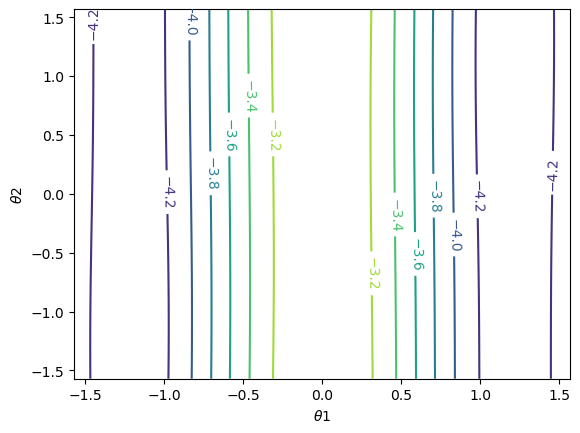

In [15]:
''' ph1 vs ph2 '''

delta = 0.005
th1 = np.arange(-np.pi/2,np.pi/2,delta)
th2 = np.arange(-np.pi/2,np.pi/2,delta)
Th1,Th2 = np.meshgrid(th1,th2)
_, _, exH = energy(np.sqrt(1-1e-5), np.sqrt(1e-5), Th1, Th2, 0, 0, a, m, n)

fig, ax = plt.subplots()
CS = ax.contour(Th1, Th2, exH.real)
# ax.plot(np.arccos(eps/(V*N-V)),0,marker='X',color='r')

ax.clabel(CS, fontsize=10)
ax.set_xlabel(r'$\theta 1$')
ax.set_ylabel(r'$\theta 2$')
plt.show()